In [1]:
import numpy as np

In [6]:
a = np.array([4,5])

In [7]:
a

array([4, 5])

In [8]:
a.ndim

1

Vector- 2D vector(Number of elements = No. of dimensions)


In [9]:
mat = np.array([[1,2,3],[4,5,6],[7,8,9]])

In [10]:
mat

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [11]:
mat.shape

(3, 3)

In [12]:
mat.size

9

Dimension of Tension is not equivalent to dimension of vector


In [13]:
tensor_3d = np.array([[[1, 2, 3], [4, 5, 6]], [[7, 8, 9], [10, 11, 12]]])
print(tensor_3d)
print(tensor_3d.shape)

[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]]
(2, 2, 3)


4D Tensors - Group of images (50,3,1200,800)
4D Tensors - Collection of frames (4,1800,720,3)
4 60 sec videos may take 2.7GB - hence video encoding is used

In [15]:
!mkdir -p ~/.kaggle
!cp kaggle\ \(1\).json ~/.kaggle/

In [17]:
!kaggle datasets download andrewmvd/face-mask-detection

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/face-mask-detection
License(s): CC0-1.0
face-mask-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [19]:
import zipfile
zip_ref = zipfile.ZipFile('/content/face-mask-detection.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

End-to-end Toy project

In [20]:
import numpy as np
import pandas as pd

In [22]:
df = pd.read_csv('placement.csv')

In [23]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [26]:
#Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split(cross validation)
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [28]:
df = df.iloc[:,1:]

In [30]:
import matplotlib.pyplot as plt


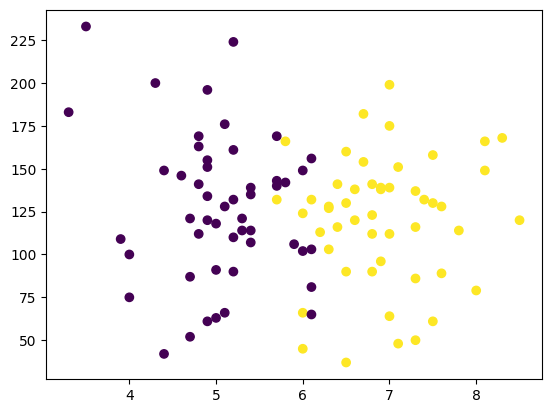

In [32]:
plt.scatter(df['cgpa'],df['iq'], c = df['placement'])

In [34]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [36]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.1,random_state=2)

In [38]:
X_train,y_train

(    cgpa     iq
 99   6.2  113.0
 92   5.2  110.0
 76   4.9  155.0
 14   6.1  103.0
 0    6.8  123.0
 ..   ...    ...
 43   6.8  141.0
 22   4.9  120.0
 72   7.3  116.0
 15   5.1  176.0
 40   4.9  134.0
 
 [90 rows x 2 columns],
 99    1
 92    0
 76    0
 14    0
 0     1
      ..
 43    1
 22    0
 72    1
 15    0
 40    0
 Name: placement, Length: 90, dtype: int64)

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

In [41]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
#model training
clf.fit(X_train,y_train)

LogisticRegression()

In [46]:
#Evaluate the model
y_pred = clf.predict(X_test)

In [45]:
y_test

,placement
83,1
30,1
56,0
24,0
16,0
23,0
2,0
27,1
28,0
13,1


In [47]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.9

In [48]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

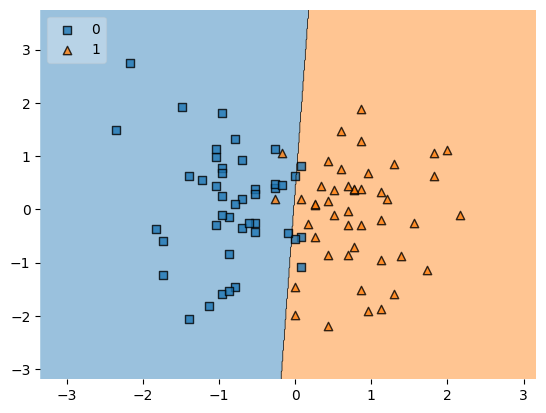

In [53]:
plot_decision_regions(X_train, y_train.values, clf= clf, legend =2)

In [55]:
import pickle
pickle.dump(clf,open('model.pkl','wb'))
#Then we can deploy the model

Working with CSV files

In [2]:
import pandas as pd


In [3]:
df = pd.read_csv('aug_train.csv')

We can also load csv files from a server

In [8]:
#Sep parameter
pd.read_csv('movie_titles_metadata.tsv', sep ='\t',names =['sno','name','year','rating','votes','genres'])

,sno,name,year,rating,votes,genres
0,m0,10 things i hate about you,1999,6.9,62847.0,['comedy' 'romance']
1,m1,1492: conquest of paradise,1992,6.2,10421.0,['adventure' 'biography' 'drama' 'history']
2,m2,15 minutes,2001,6.1,25854.0,['action' 'crime' 'drama' 'thriller']
3,m3,2001: a space odyssey,1968,8.4,163227.0,['adventure' 'mystery' 'sci-fi']
4,m4,48 hrs.,1982,6.9,22289.0,['action' 'comedy' 'crime' 'drama' 'thriller']
...,...,...,...,...,...,...
612,m612,watchmen,2009,7.8,135229.0,['action' 'crime' 'fantasy' 'mystery' 'sci-fi'...
613,m613,xxx,2002,5.6,53505.0,['action' 'adventure' 'crime']
614,m614,x-men,2000,7.4,122149.0,['action' 'sci-fi']
615,m615,young frankenstein,1974,8.0,57618.0,['comedy' 'sci-fi']


In [11]:
#Index_col parameter
pd.read_csv('aug_train.csv',index_col='enrollee_id')

,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
enrollee_id,,,,,,,,,,,,,
8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0


In [12]:
#Header parameter
pd.read_csv('test.csv',header=1)

,0,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
1,2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
2,3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
3,4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


In [13]:
#usecols parameter
pd.read_csv('aug_train.csv',usecols=['enrollee_id','gender','education_level'])

,enrollee_id,gender,education_level
0,8949,Male,Graduate
1,29725,Male,Graduate
2,11561,NaN,Graduate
3,33241,NaN,Graduate
4,666,Male,Masters
...,...,...,...
19153,7386,Male,Graduate
19154,31398,Male,Graduate
19155,24576,Male,Graduate
19156,5756,Male,High School


In [16]:
#squeeze parameters - NOW DOESN'T EXIST
pd.read_csv('aug_train.csv',usecols=['gender'])['gender']

,gender
0,Male
1,Male
2,NaN
3,NaN
4,Male
...,...
19153,Male
19154,Male
19155,Male
19156,Male


In [22]:
#Skiprows and nrows= N
pd.read_csv('aug_train.csv', skiprows = lambda x :x%4 != 0)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
1,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1.0
2,23853,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,5,5000-9999,Pvt Ltd,1,108,0.0
3,6588,city_114,0.926,Male,Has relevent experience,no_enrollment,Graduate,STEM,16,10/49,Pvt Ltd,>4,18,0.0
4,11399,city_13,0.827,Female,Has relevent experience,no_enrollment,Graduate,Arts,4,NaN,NaN,1,132,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4784,5603,city_21,0.624,NaN,Has relevent experience,Full time course,Graduate,STEM,4,NaN,NaN,NaN,13,0.0
4785,33047,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,10000+,Pvt Ltd,>4,18,0.0
4786,21319,city_21,0.624,Male,No relevent experience,Full time course,Graduate,STEM,1,100-500,Pvt Ltd,1,52,1.0
4787,11385,city_149,0.689,Male,No relevent experience,Full time course,Graduate,NaN,2,NaN,NaN,1,60,0.0


In [24]:
# Encoding parameter - usually its UTF-8
pd.read_csv('zomato.csv',encoding='latin-1')

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901


In [ ]:
#Skip bad lines
pd.read_csv('BX-Books.csv', sep=';', encoding="latin-1",error_bad_lines=False)

In [28]:
pd.read_csv('aug_train.csv',dtype={'target':int})

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0


In [30]:
pd.read_csv('/content/IPL Matches 2008-2020.csv',parse_dates=['date']).info()
#

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               816 non-null    int64         
 1   city             803 non-null    object        
 2   date             816 non-null    datetime64[ns]
 3   player_of_match  812 non-null    object        
 4   venue            816 non-null    object        
 5   neutral_venue    816 non-null    int64         
 6   team1            816 non-null    object        
 7   team2            816 non-null    object        
 8   toss_winner      816 non-null    object        
 9   toss_decision    816 non-null    object        
 10  winner           812 non-null    object        
 11  result           812 non-null    object        
 12  result_margin    799 non-null    float64       
 13  eliminator       812 non-null    object        
 14  method           19 non-null     object   

In [34]:
#convertors
def rename(name):
  if name == "Royal Challengers Bangalore":
    return "RCB"
  else:
    return name
pd.read_csv('/content/IPL Matches 2008-2020.csv',converters={'team1':rename,'team2':rename})

,id,city,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
0,335982,Bangalore,2008-04-18,BB McCullum,M Chinnaswamy Stadium,0,RCB,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,Chandigarh,2008-04-19,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",0,Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,N,NaN,MR Benson,SL Shastri
2,335984,Delhi,2008-04-19,MF Maharoof,Feroz Shah Kotla,0,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,Mumbai,2008-04-20,MV Boucher,Wankhede Stadium,0,Mumbai Indians,RCB,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,N,NaN,SJ Davis,DJ Harper
4,335986,Kolkata,2008-04-20,DJ Hussey,Eden Gardens,0,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,N,NaN,BF Bowden,K Hariharan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
811,1216547,Dubai,2020-09-28,AB de Villiers,Dubai International Cricket Stadium,0,RCB,Mumbai Indians,Mumbai Indians,field,Royal Challengers Bangalore,tie,NaN,Y,NaN,Nitin Menon,PR Reiffel
812,1237177,Dubai,2020-11-05,JJ Bumrah,Dubai International Cricket Stadium,0,Mumbai Indians,Delhi Capitals,Delhi Capitals,field,Mumbai Indians,runs,57.0,N,NaN,CB Gaffaney,Nitin Menon
813,1237178,Abu Dhabi,2020-11-06,KS Williamson,Sheikh Zayed Stadium,0,RCB,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Sunrisers Hyderabad,wickets,6.0,N,NaN,PR Reiffel,S Ravi
814,1237180,Abu Dhabi,2020-11-08,MP Stoinis,Sheikh Zayed Stadium,0,Delhi Capitals,Sunrisers Hyderabad,Delhi Capitals,bat,Delhi Capitals,runs,17.0,N,NaN,PR Reiffel,S Ravi


In [35]:
#na_values parameter
pd.read_csv('/content/aug_train.csv',na_values=['Male',])

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,NaN,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,NaN,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,NaN,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,NaN,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


In [37]:
#Loading a huge dataset in chunks
dfs= pd.read_csv('/content/aug_train.csv',chunksize=5000)

In [38]:
for chunk in dfs:
  print(chunk.shape)

(5000, 14)
(5000, 14)
(5000, 14)
(4158, 14)


Working with Json and SQL

In [40]:
pd.read_json('train.json')

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."
...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ..."
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b..."
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte..."
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli..."


In [42]:
pd.read_json('https://api.exchangerate-api.com/v4/latest/INR')

,provider,WARNING_UPGRADE_TO_V6,terms,base,date,time_last_updated,rates
INR,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,1.0000
AED,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,0.0389
AFN,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,0.6770
ALL,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,0.8740
AMD,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,3.9000
...,...,...,...,...,...,...,...
YER,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,2.5300
ZAR,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,0.1740
ZMW,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,0.1890
ZWG,https://www.exchangerate-api.com,https://www.exchangerate-api.com/docs/free,https://www.exchangerate-api.com/terms,INR,2026-06-21,1782000001,0.2840


In [43]:
!pip install mysql.connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 64.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mysql.connector: filename=mysql_connector-2.2.9-cp312-cp312-linux_x86_64.whl size=247950 sha256=249e1ca7f49455413327c1dbc75fc541c56a998f7861a4b2b046df8a2ec8c314
  Stored in directory: /root/.cache/pip/wheels/03/17/fa/d7604c72dd3dd6d3eb3d249abf36cc532c9a9b4354b8f1bc4f
Successfully built mysql.connector


In [50]:
import mysql.connector
conn = mysql.connector.connect(host = 'localhost',user = 'root',password = '',database = 'flipkart')

InterfaceError: 2003: Can't connect to MySQL server on 'localhost:3306' (111 Connection refused)

In [48]:
# The 'InterfaceError: 2003: Can't connect to MySQL server on 'localhost:3306''
# occurs because 'localhost' in Google Colab refers to the Colab runtime,
# which does not have a MySQL server running by default.

# To connect to a MySQL database from Colab, you need an external MySQL server
# (e.g., on a cloud platform or a remote machine) and its connection details.

# Example of how you would connect to a remote MySQL server (replace placeholders):
# import mysql.connector
# try:
#     db_connection = mysql.connector.connect(
#         host='your_mysql_server_host',  # e.g., 'your.database.cloud.com'
#         user='your_username',
#         password='your_password',
#         database='your_database_name'
#     )
#     if db_connection.is_connected():
#         print("Successfully connected to MySQL database!")
#         # You can now create a cursor and execute queries
#         # cursor = db_connection.cursor()
#         # cursor.execute("SELECT * FROM your_table")
#         # result = cursor.fetchall()
#         # print(result)
#     db_connection.close()
# except mysql.connector.Error as err:
#     print(f"Error: {err}")


In [ ]:
# pd.read_sql_query("SELECT * FROM county",conn)